In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from torch.utils.data.distributed import DistributedSampler
from torchsummary import summary
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.neighbors import NearestNeighbors
import random

cv2.setNumThreads(0)

In [2]:
class ImageDataset(Dataset):
	def __init__(self,ImgDirName):
		super().__init__()
		self.Buckets = np.load('CoordBuckets.npy')
		self.NearestNeighbour = NearestNeighbors(n_neighbors=1,algorithm='auto').fit(self.Buckets)
		self.ImgPaths = []
		for ImgName in os.listdir(ImgDirName):
			ImgPath = os.path.join(ImgDirName,ImgName)
			if os.path.isfile(ImgPath):
				self.ImgPaths.append(ImgPath)

	def __len__(self):
		return len(self.ImgPaths)
	
	def __getitem__(self, index):
		try:
			InputImg = cv2.imread(self.ImgPaths[index])
			if InputImg is None:
				raise ValueError(f"OpenCV could not read image: {self.ImgPaths[index]}")

			h,w = InputImg.shape[:2]
			if h<w:
				nw = int(w*(256/h))
				nh = 256
			else:
				nw = 256
				nh = int(h*(256/w))
			
			ResizedImg = cv2.resize(InputImg,(nw,nh),interpolation=cv2.INTER_AREA)
			StartX = max(0,(nw-256)//2)
			StartY = max(0,(nh-256)//2)
			CroppedImg = ResizedImg[StartY:StartY+256,StartX:StartX+256]

			if CroppedImg.shape[:2] != (256, 256):
				raise ValueError(f"Geometry Anomaly. Image {self.ImgPaths[index]}")

			LABImg = cv2.cvtColor(CroppedImg,cv2.COLOR_BGR2LAB)
			InputChannel = (torch.from_numpy(LABImg[:,:,0:1]).float()/255.0).permute(2,0,1)
			OutputChannels = LABImg[:,:,1:3].astype(np.float32) - 128.0
			OutputChannels = OutputChannels.reshape(-1,2)
			
			_,Indices = self.NearestNeighbour.kneighbors(OutputChannels)
			OutputTensor = torch.from_numpy(Indices.reshape(256,256)).long()

			return (InputChannel,OutputTensor)
		
		except ValueError:
			RandomFallback = random.randint(0, len(self.ImgPaths) - 1)
			return self.__getitem__(RandomFallback)

In [3]:
class PrismModel(nn.Module):
	def __init__(self):
		super().__init__()

		self.DownBlock1 = nn.Sequential(
			nn.Conv2d(in_channels=1,out_channels=64,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(64),
			nn.SiLU(),
			nn.Conv2d(in_channels=64,out_channels=64,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(64),
			nn.SiLU()
		)
		self.DownBlock2 = nn.Sequential(
			nn.Conv2d(in_channels=64,out_channels=128,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(128),
			nn.SiLU(),
			nn.Conv2d(in_channels=128,out_channels=128,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(128),
			nn.SiLU()
		)
		self.DownBlock3 = nn.Sequential(
			nn.Conv2d(in_channels=128,out_channels=256,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(256),
			nn.SiLU(),
			nn.Conv2d(in_channels=256,out_channels=256,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(256),
			nn.SiLU()
		)
		self.DownBlock4 = nn.Sequential(
			nn.Conv2d(in_channels=256,out_channels=512,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(512),
			nn.SiLU(),
			nn.Conv2d(in_channels=512,out_channels=512,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(512),
			nn.SiLU(),
			nn.Dropout(0.5),
			nn.ConvTranspose2d(in_channels=512,out_channels=256,kernel_size=2,stride=2)
		)
		self.UpBlock1 = nn.Sequential(
			nn.Conv2d(in_channels=512,out_channels=256,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(256),
			nn.SiLU(),
			nn.Conv2d(in_channels=256,out_channels=256,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(256),
			nn.SiLU(),
			nn.ConvTranspose2d(in_channels=256,out_channels=128,kernel_size=2,stride=2)
		)
		self.UpBlock2 = nn.Sequential(
			nn.Conv2d(in_channels=256,out_channels=128,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(128),
			nn.SiLU(),
			nn.Conv2d(in_channels=128,out_channels=128,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(128),
			nn.SiLU(),
			nn.ConvTranspose2d(in_channels=128,out_channels=64,kernel_size=2,stride=2)
		)
		self.UpBlock3 = nn.Sequential(
			nn.Conv2d(in_channels=128,out_channels=64,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(64),
			nn.SiLU(),
			nn.Conv2d(in_channels=64,out_channels=64,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(64),
			nn.SiLU()
		)
		self.UpConv4 = nn.Conv2d(in_channels=64,out_channels=313,kernel_size=(3,3),padding=1)
		self.MaxPool1 = nn.MaxPool2d((2,2))
		self.Upsample1 = nn.ConvTranspose2d

	def forward(self,x):
		x1 = self.DownBlock1(x)
		x2 = self.MaxPool1(x1)
		x2 = self.DownBlock2(x2)
		x3 = self.MaxPool1(x2)
		x3 = self.DownBlock3(x3)
		x4 = self.MaxPool1(x3)
		x4 = self.DownBlock4(x4)
		x3 = self.UpBlock1(torch.cat((x4,x3),dim=1))
		x2 = self.UpBlock2(torch.cat((x3,x2),dim=1))
		x1 = self.UpBlock3(torch.cat((x2,x1),dim=1))
		x = self.UpConv4(x1)

		return x

In [4]:
PriorProbs = np.load('PriorProbs.npy')
Lambda = 0.5
Q = 313.0
SmotheredProbs = ((1.0-Lambda)*PriorProbs) + (Lambda/Q)
Weights = 1.0/SmotheredProbs
NormalisationFactor = np.sum(PriorProbs*Weights)
Weights /= NormalisationFactor

BatchSize = 7

TrainDirName = 'TrainDataset'
ValDirName = 'ValDataset'
TestDirName = 'TestDataset'

In [5]:
def DDPTrainLoop(rank,GPUCount,Weights,BatchSize,TrainDirName,ValDirName):
	os.environ['MASTER_ADDR'] = 'localhost'
	os.environ['MASTER_PORT'] = '12355'
	
	dist.init_process_group('nccl',rank=rank,world_size=GPUCount)
	torch.cuda.set_device(rank)
	device = torch.device(f'cuda:{rank}')

	model = PrismModel().to(device)
	model = nn.SyncBatchNorm.convert_sync_batchnorm(model)

	if rank == 0:
		print('Model Summary: ')
		summary(model,input_size=(1,256,256))

	Weights = torch.from_numpy(Weights).float().squeeze().to(device)
	
	criterion = nn.CrossEntropyLoss(weight=Weights)
	optimiser = optim.Adam(model.parameters(), lr=1e-4)
	scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser,mode='min',factor=0.1,patience=10,threshold=1e-5)

	TrainDataset = ImageDataset(TrainDirName)
	ValDataset = ImageDataset(ValDirName)

	TrainSampler = DistributedSampler(TrainDataset,num_replicas=GPUCount,rank=rank,shuffle=True)
	ValSampler = DistributedSampler(ValDataset,num_replicas=GPUCount,rank=rank,shuffle=False)

	TrainLoader = DataLoader(TrainDataset,batch_size=BatchSize,sampler=TrainSampler,num_workers=2,pin_memory=True)
	ValLoader = DataLoader(ValDataset,batch_size=BatchSize,sampler=ValSampler,num_workers=2,pin_memory=True)

	if os.path.exists('PrismModel.pth'):
		if rank == 0:
			print('Loaded previous session!')
		Checkpoint = torch.load('PrismModel.pth',map_location=device)

		model.load_state_dict(Checkpoint['ModelState'])
		optimiser.load_state_dict(Checkpoint['OptimiserState'])
		ImagesSeen = Checkpoint['ImagesSeen']
		BestLoss = Checkpoint['BestLoss']
		TrainLossHist = Checkpoint['TrainLossHist']
		ValLossHist = Checkpoint['ValLossHist']
	else:
		if rank == 0:
			print('Starting new session')
		ImagesSeen = 0
		BestLoss = float('inf')
		TrainLossHist = []
		ValLossHist = []

	model = DDP(model,device_ids=[rank])

	if rank == 0:
		print('Starting train session...')

	RunningLoss = 0.0
	MaxPatience = 30
	PatienceCounter = 0
	MaxEpochs = 1000
	Accumulation = 8

	try:
		for epoch in range(MaxEpochs):
			TrainSampler.set_epoch(epoch)
			model.train()
			for BatchIdx,(inputs,targets) in enumerate(TrainLoader):
				inputs = inputs.to(device)
				targets = targets.to(device)

				predictions = model(inputs)
				loss = criterion(predictions,targets)
				loss = loss/Accumulation
				loss.backward()

				if (BatchIdx + 1) % Accumulation == 0:
					optimiser.step()
					optimiser.zero_grad()

				RunningLoss += (loss.item()*Accumulation)
				ImagesSeen += inputs.size(0)

				# if (BatchIdx+1) % (LogInterval/10) == 0:
				# 	print(f'Processed {ImagesSeen} Images...')

			model.eval()
			ValLossTotal = 0.0
			with torch.no_grad():
				for ValImgs,ValTargets in ValLoader:
					ValImgs = ValImgs.to(device)
					ValTargets = ValTargets.to(device)

					ValPrediction = model(ValImgs)
					ValLoss = criterion(ValPrediction,ValTargets)
					ValLossTotal += ValLoss.item()
					
			LocalAvgLoss = ValLossTotal/len(ValLoader)
			LossTensor = torch.tensor([LocalAvgLoss],device=device)
			dist.all_reduce(LossTensor,op=dist.ReduceOp.SUM)
			GlobalAvgLoss = LossTensor.item()/GPUCount

			TrainLossHist.append((RunningLoss/len(TrainLoader)))
			ValLossHist.append(GlobalAvgLoss)

			scheduler.step(GlobalAvgLoss)

			if rank == 0:
				print(f"Epoch: {epoch+1} | Training Loss: {(RunningLoss/len(TrainLoader)):.6f} | Validation Loss: {GlobalAvgLoss:.6f}")

			if GlobalAvgLoss < BestLoss:
				BestLoss = GlobalAvgLoss

				if rank == 0:
					print(f"Validation Loss has decreased! Saving model!")
					Checkpoint = {
						'ModelState':model.module.state_dict(),
						'OptimiserState':optimiser.state_dict(),
						'ImagesSeen':ImagesSeen,
						'BestLoss':BestLoss,
						'TrainLossHist':TrainLossHist,
						'ValLossHist':ValLossHist
					}

					torch.save(Checkpoint,'PrismModel.pth')
				PatienceCounter = 0
			else:
				PatienceCounter += 1
				if rank == 0:
					print(f'No improvement... Patience: {PatienceCounter}/{MaxPatience}')

				if (PatienceCounter >= MaxPatience):
					print('Patience limit reached. Stopping...')
					break
			
			RunningLoss = 0.0
			model.train()

	except KeyboardInterrupt:
		if rank == 0:
			print(f"Keyboard Interrupt! Saving model!")

			Checkpoint = {
				'ModelState':model.module.state_dict(),
				'OptimiserState':optimiser.state_dict(),
				'ImagesSeen':ImagesSeen,
				'BestLoss':BestLoss
			}

			torch.save(Checkpoint,'PrismModel.pth')
			
	dist.destroy_process_group()

In [6]:
if __name__ == '__main__':
	if torch.cuda.is_available():
		print("PyTorch is using the GPU")
		GPUCount = torch.cuda.device_count()
		print(f"Found {GPUCount} GPUs")

		for i in range(GPUCount):
			print(f"GPU {i} found: {torch.cuda.get_device_name(i)}")
	else:
		GPUCount = 0
		print("PyTorch is using the CPU")

	if GPUCount > 1:
		print('Multiple GPUs detected! Switching to DDP...')
		mp.spawn(
			DDPTrainLoop,
			args=(GPUCount,Weights,BatchSize,TrainDirName,ValDirName),
			nprocs=GPUCount,
			join=True
		)
	else:
		print('Single device detected...')
		GPUCount = 1
		DDPTrainLoop(
			0,
			GPUCount,
			Weights,
			BatchSize,
			TrainDirName,
			ValDirName
		)

PyTorch is using the GPU
Found 1 GPUs
GPU 0 found: NVIDIA GeForce RTX 5070 Laptop GPU
Single device detected...
Model Summary: 
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]             640
     SyncBatchNorm-2         [-1, 64, 256, 256]             128
              SiLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,928
     SyncBatchNorm-5         [-1, 64, 256, 256]             128
              SiLU-6         [-1, 64, 256, 256]               0
         MaxPool2d-7         [-1, 64, 128, 128]               0
            Conv2d-8        [-1, 128, 128, 128]          73,856
     SyncBatchNorm-9        [-1, 128, 128, 128]             256
             SiLU-10        [-1, 128, 128, 128]               0
           Conv2d-11        [-1, 128, 128, 128]         147,584
    SyncBatchNorm-12        [-1, 128, 1

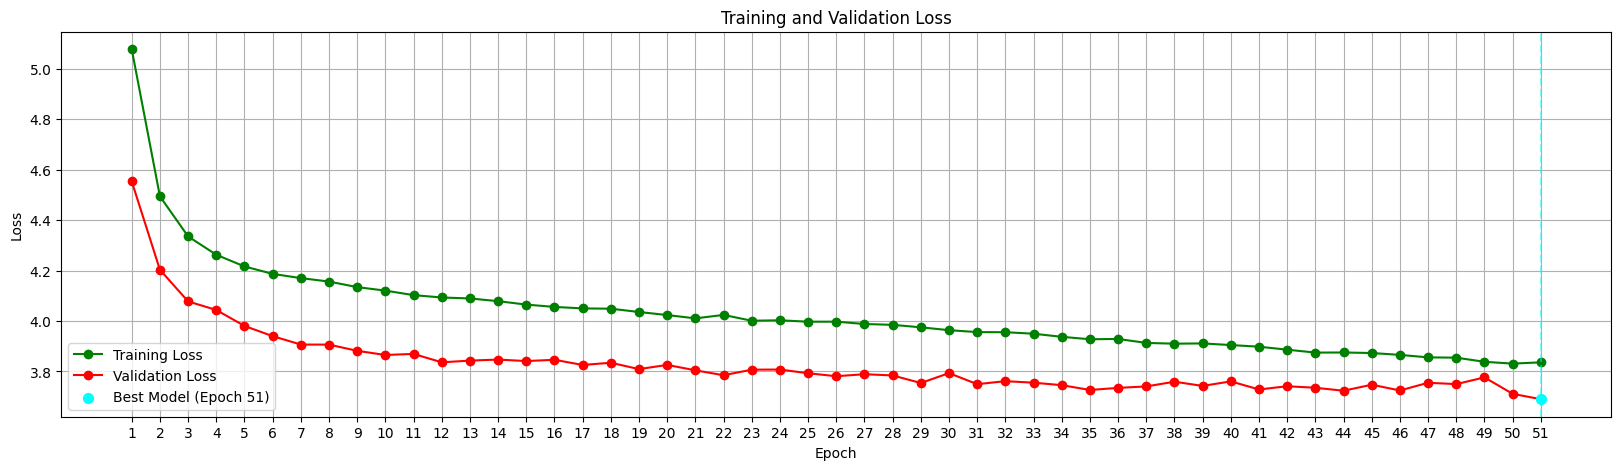

In [7]:
Data = torch.load('PrismModel.pth',map_location='cpu')
TrainLossHist = Data['TrainLossHist']
ValLossHist = Data['ValLossHist']
BestLoss = Data['BestLoss']

#Plotting
EpochCount = range(1, len(TrainLossHist) + 1)
MinLossEpoch = EpochCount[ValLossHist.index(BestLoss)]

#Training and Validation Loss
plt.figure(figsize=(20,5))
plt.plot(EpochCount,TrainLossHist,label='Training Loss',color='green',marker='o')
plt.plot(EpochCount,ValLossHist,label='Validation Loss',color='red',marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.xticks(EpochCount)
plt.ylabel('Loss')
plt.grid(True)
plt.axvline(MinLossEpoch,linestyle='--',color='cyan',alpha=0.5)
plt.scatter(MinLossEpoch, BestLoss, c='cyan', s=50, marker='o', zorder=10, label=f'Best Model (Epoch {MinLossEpoch})')
plt.legend()
plt.show()

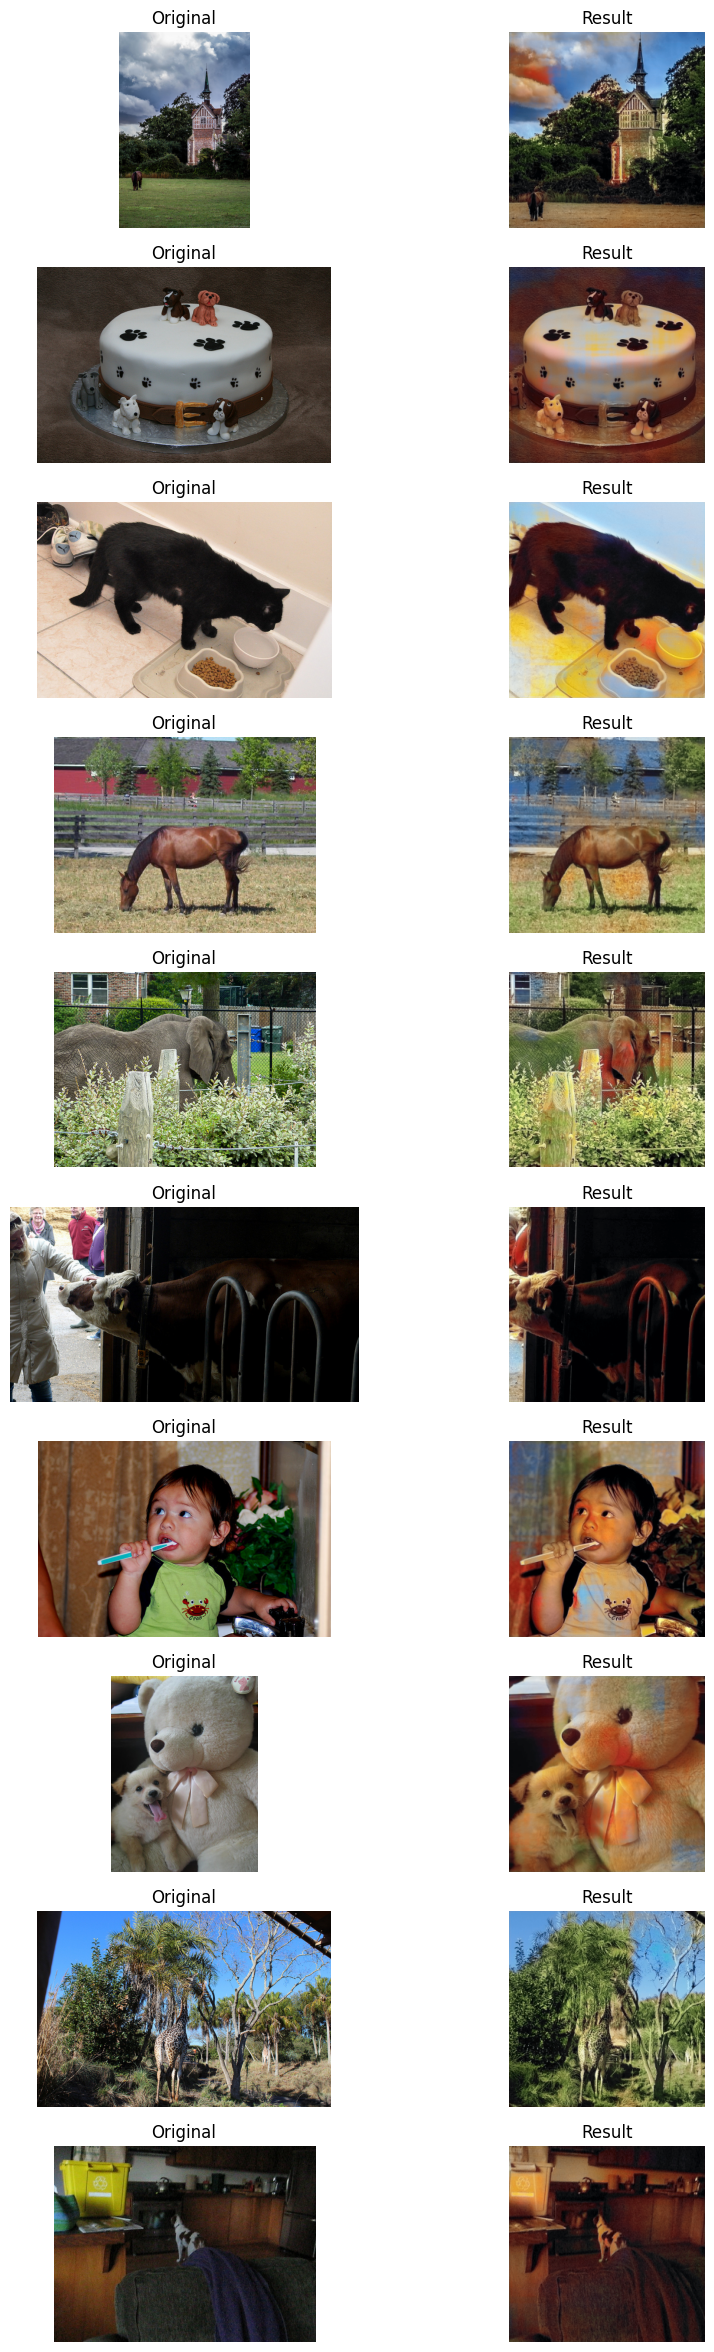

In [10]:
if torch.cuda.is_available():
	device = torch.device("cuda:0")
else:
	device = torch.device("cpu")

Buckets = torch.from_numpy(np.load('CoordBuckets.npy')).float().to(device)
Temperature = 0.38

checkpoint = torch.load('PrismModel.pth',map_location=device)

model = PrismModel().to(device)
model.load_state_dict(checkpoint['ModelState'])
model.eval()

ValidImages = [img for img in os.listdir(TestDirName) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
NumImages = len(ValidImages)

plt.figure(figsize=(10,3*NumImages))

with torch.no_grad():
	for ImgId,ImgName in enumerate(ValidImages):
		ImgPath = os.path.join(TestDirName,ImgName)
		if os.path.isfile(ImgPath):
			TestImg = cv2.imread(ImgPath)

			h,w = TestImg.shape[:2]
			if h<w:
				nw = int(w*(256/h))
				nh = 256
			else:
				nw = 256
				nh = int(h*(256/w))
			
			ResizedImg = cv2.resize(TestImg,(nw,nh),interpolation=cv2.INTER_AREA)
			StartX = (nw-256)//2
			StartY = (nh-256)//2
			CroppedImg = ResizedImg[StartY:StartY+256,StartX:StartX+256]

			TestLab = cv2.cvtColor(CroppedImg,cv2.COLOR_BGR2LAB)
			TestInp = (torch.from_numpy(TestLab[:,:,0:1]).float()/255.0).permute(2,0,1).unsqueeze(0).to(device)
			TestOut = model(TestInp)
			Probs = torch.softmax(TestOut/Temperature,dim=1)
			TestOut = torch.einsum('bchw,cd->bdhw',Probs,Buckets)
			TestInp *= 255.0
			TestOut += 128.0
			TestResRaw = torch.concat((TestInp,TestOut),dim=1).squeeze(0).permute(1,2,0).cpu().detach().numpy()
			TestResNorm = np.clip(TestResRaw,0,255).astype(np.uint8)

			plt.subplot(NumImages,2,(2*ImgId+1))
			plt.title('Original')
			plt.axis('off')
			plt.imshow(cv2.cvtColor(TestImg,cv2.COLOR_BGR2RGB))
			
			plt.subplot(NumImages,2,(2*ImgId+2))
			plt.title('Result')
			plt.axis('off')
			plt.imshow(cv2.cvtColor(TestResNorm,cv2.COLOR_LAB2RGB))